<a href="https://colab.research.google.com/github/Surya-Girish/SmartGridFDIDetection/blob/Surya/XTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import math
import warnings
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from numpy.linalg import norm
warnings.filterwarnings('ignore')


class Encoder(nn.Module):
  def __init__(self, input_dim, head_size, num_heads, ff_dim, dropout):
    super().__init__()
    self.input_dim = input_dim
    self.embed_dim = head_size*num_heads
    self.num_heads = num_heads
    self.ff_dim = ff_dim
    self.dropout = dropout
    self.Attention = nn.MultiheadAttention(self.embed_dim, self.num_heads, self.dropout, batch_first = True)
    self.dropout1 = nn.Dropout(self.dropout)
    self.norm1 = nn.LayerNorm(self.embed_dim)

    self.ffn = nn.Sequential(
            nn.Linear(self.embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, self.embed_dim),
            nn.ReLU()
        )
    self.norm2 = nn.LayerNorm(self.embed_dim)
    self.dropout2 = nn.Dropout(self.dropout)

  def forward(self, x):
    attn, _ = self.Attention(x, x, x)
    x = x + self.dropout1(attn)
    x = self.norm1(x)
    x = x + self.dropout2(self.ffn(x))
    x = self.norm2(x)
    return x

class XTMModel(nn.Module):
    def __init__(self, input_dim, head_size, num_heads, ff_dim, num_blocks, mlp_units, mlp_dropout, dropout):
        super().__init__()

        self.transformer_blocks = nn.ModuleList([
            Encoder(input_dim, head_size, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])

        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=128, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True)

        mlp_layers = []
        curr_dim = 128
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim
        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        for block in self.transformer_blocks:
            x = block(x)

        x, _ = self.lstm1(x)
        _, (h_n, _) = self.lstm2(x)
        x = h_n[-1]

        x = self.mlp(x)

        return [head(x) for head in self.heads]


class CNNTransformerModel(nn.Module):
    def __init__(self, input_dim, head_size, num_heads, ff_dim, num_blocks, mlp_units, dropout, mlp_dropout):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=128, kernel_size=9)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.transformer_blocks = nn.ModuleList([
            Encoder(128, head_size, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])

        mlp_layers = []
        curr_dim = 128
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim

        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        x = x.transpose(1, 2)

        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = x.transpose(1, 2)

        for block in self.transformer_blocks:
            x = block(x)

        x = x.mean(dim=1)

        x = self.mlp(x)
        return [head(x) for head in self.heads]

class CNNModel(nn.Module):
    def __init__(self, input_dim, mlp_units, mlp_dropout):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=128, kernel_size=9)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=128, kernel_size=9)

        mlp_layers = []
        curr_dim = 128
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim

        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        x = x.transpose(1, 2)

        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))

        x = torch.mean(x, dim=2)

        x = self.mlp(x)
        return [head(x) for head in self.heads]



class CNNLSTMModel(nn.Module):
    def __init__(self, input_dim, mlp_units, mlp_dropout):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=128, kernel_size=9)
        self.pool1 = nn.MaxPool1d(kernel_size=3)

        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True)

        mlp_layers = []
        curr_dim = 128
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim
        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        x = x.transpose(1, 2)
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = x.transpose(1, 2)

        x, _ = self.lstm1(x)

        _, (h_n, _) = self.lstm2(x)
        x = h_n[-1]

        x = self.mlp(x)
        return [head(x) for head in self.heads]


class TransformerModel(nn.Module):
    def __init__(self, input_dim, head_size, num_heads, ff_dim, num_blocks, mlp_units, mlp_dropout, dropout):
        super().__init__()

        self.transformer_blocks = nn.ModuleList([
            TransformerEncoder(input_dim, head_size, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])

        mlp_layers = []
        curr_dim = input_dim
        for dim in mlp_units:
            mlp_layers.append(nn.Linear(curr_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(mlp_dropout))
            curr_dim = dim

        self.mlp = nn.Sequential(*mlp_layers)

        self.heads = nn.ModuleList([nn.Linear(curr_dim, 1) for _ in range(54)])

    def forward(self, x):
        for block in self.transformer_blocks:
            x = block(x)

        x = x.mean(dim=1)

        x = self.mlp(x)
        return [head(x) for head in self.heads]


In [32]:
class XTMModelManager:
    def __init__(self, model, scaler, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.model = model.to(device)
        self.device = device
        self.scaler = scaler # Store the scaler instance directly
        self.history = {'loss': [], 'val_loss': []}
        self.optimizer = None
        self.criterion = None

    # --- Training & Prediction ---
    def compile_model(self, loss_function, optimizer_class, lr=0.001):
        self.criterion = loss_function
        self.optimizer = optimizer_class(self.model.parameters(), lr=lr)

    def train(self, train_loader, val_loader, epochs=50, save_path=None):
        for epoch in range(epochs):
            self.model.train()
            train_loss = 0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = sum([self.criterion(out.squeeze(), batch_y[:, i]) for i, out in enumerate(outputs)])
                loss.backward()
                self.optimizer.step()
                train_loss += loss.item()

            val_loss = self.evaluate_loss(val_loader)
            self.history['loss'].append(train_loss / len(train_loader))
            self.history['val_loss'].append(val_loss)
            print(f"Epoch {epoch+1}/{epochs} - loss: {self.history['loss'][-1]:.6f} - val_loss: {val_loss:.6f}")

    def evaluate_loss(self, loader):
        self.model.eval()
        total_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                outputs = self.model(batch_x)
                total_loss += sum([self.criterion(out.squeeze(), batch_y[:, i]) for i, out in enumerate(outputs)]).item()
        return total_loss / len(loader)

    def predict(self, loader):
        self.model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_x, _ in loader:
                batch_x = batch_x.to(self.device)
                outputs = self.model(batch_x)
                preds = torch.stack([out.squeeze() for out in outputs], dim=1)
                all_preds.append(preds.cpu().numpy())
        return np.vstack(all_preds)

    # --- Metrics & Analysis ---
    def get_regression_metrics(self, y_true, y_pred):
        """Standard MAE/MSE on inverse-scaled data."""
        # Use the stored scaler to inverse transform
        y_true_inv = self.scaler.inverse_transform(y_true)
        y_pred_inv = self.scaler.inverse_transform(y_pred)

        mae = np.mean(np.abs(y_true_inv - y_pred_inv))
        mse = np.mean((y_true_inv - y_pred_inv)**2)
        rmse = np.sqrt(mse)
        return {"mae": mae, "mse": mse, "rmse": rmse}

    def get_fdi_metrics(self, y_observed, y_predicted_benign, y_true_binary_labels, threshold=0.4):
        """Calculates PRF by treating error > threshold as an anomaly.
        Errors are calculated on the normalized data directly, and threshold is applied to L2 norm of error.
        """
        # Calculate L2 norm of error per sample across 54 features on normalized data
        # y_observed: the actual observed values (can be benign or attacked)
        # y_predicted_benign: the model's prediction assuming no attack (expected benign)
        errors_per_sample = np.linalg.norm(y_observed - y_predicted_benign, axis=1)

        y_pred_binary = (errors_per_sample > threshold).astype(int)

        metrics = {
            "precision": precision_score(y_true_binary_labels, y_pred_binary, zero_division=0),
            "recall": recall_score(y_true_binary_labels, y_pred_binary, zero_division=0),
            "f1": f1_score(y_true_binary_labels, y_pred_binary, zero_division=0),
            "accuracy": accuracy_score(y_true_binary_labels, y_pred_binary),
            "cm": confusion_matrix(y_true_binary_labels, y_pred_binary, labels=[0, 1])
        }
        return metrics

    # --- Graphing Functions ---
    def plot_history(self):
        plt.figure(figsize=(10, 4))
        plt.plot(self.history['loss'], label='Train Loss', color='blue')
        plt.plot(self.history['val_loss'], label='Val Loss', color='red', linestyle='--')
        plt.title('Model Training History')
        plt.xlabel('Epochs')
        plt.ylabel('Loss (MSE)')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'FDI'], yticklabels=['Normal', 'FDI'])
        plt.title('FDI Detection Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

    def plot_sample_comparison(self, y_true, y_pred, sample_idx=0):
        """Plots the 54-feature vector comparison for a single time step."""
        plt.figure(figsize=(15, 5))
        plt.plot(y_true[sample_idx], label='Actual', marker='o', alpha=0.7)
        plt.plot(y_pred[sample_idx], label='Predicted', marker='x', alpha=0.7)
        plt.title(f'Feature Vector Comparison (Sample {sample_idx})')
        plt.xlabel('Feature Index (Lines 1-40, Cons 1-14)')
        plt.ylabel('Normalized Value')
        plt.legend()
        plt.show()

In [33]:
config = {
    'HOURLY_PATH': '/content/hourly_dataset.csv',
    'DATASET_PATH': '/content/fdi_attack_vector.xlsx - Sheet1.csv',
    'WINDOW': 48,
    'BASE_MVA': 100.0,
    'RANDOM_SEED': 42
}

WINDOW = config['WINDOW']

INPUT_DIM = 54
HEAD_SIZE = 9
NUM_HEADS = 6
FF_DIM = 128
NUM_BLOCKS = 1
MLP_UNITS = [128]
MLP_DROPOUT = 0.1
DROPOUT = 0.1
LEARNING_RATE = 1e-4
EPOCHS = 50

print(f"WINDOW: {WINDOW}")
print(f"INPUT_DIM: {INPUT_DIM}")
print(f"HEAD_SIZE: {HEAD_SIZE}")
print(f"NUM_HEADS: {NUM_HEADS}")
print(f"FF_DIM: {FF_DIM}")
print(f"NUM_BLOCKS: {NUM_BLOCKS}")
print(f"MLP_UNITS: {MLP_UNITS}")
print(f"MLP_DROPOUT: {MLP_DROPOUT}")
print(f"DROPOUT: {DROPOUT}")
print(f"LEARNING_RATE: {LEARNING_RATE}")
print(f"EPOCHS: {EPOCHS}")

WINDOW: 48
INPUT_DIM: 54
HEAD_SIZE: 9
NUM_HEADS: 6
FF_DIM: 128
NUM_BLOCKS: 1
MLP_UNITS: [128]
MLP_DROPOUT: 0.1
DROPOUT: 0.1
LEARNING_RATE: 0.0001
EPOCHS: 50


In [34]:
from sklearn.preprocessing import MinMaxScaler

def load_and_normalize(config):
    print("Loading and normalizing hourly dataset...")
    df_h = pd.read_csv(config['HOURLY_PATH'])
    cols = [f'line_{i}' for i in range(1, 41)] + [f'Cons_{i}' for i in range(1, 15)]
    data_mw = df_h[cols].values.astype(np.float32)

    # Split into training and validation sets before scaling to prevent data leakage
    X_train_raw, X_val_raw = train_test_split(data_mw, test_size=0.2, random_state=config['RANDOM_SEED'], shuffle=False)

    # Initialize MinMaxScaler
    scaler = MinMaxScaler()

    # Fit scaler only on the training data and transform both train and validation data
    X_train = scaler.fit_transform(X_train_raw)
    X_val = scaler.transform(X_val_raw)

    print(f"Original data shape: {data_mw.shape}")
    print(f"Normalized data shape (after splitting): {np.vstack([X_train, X_val]).shape}")
    print(f"Training set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")

    return X_train, X_val, scaler

In [35]:
X_train, X_val, scaler = load_and_normalize(config)

Loading and normalizing hourly dataset...
Original data shape: (8760, 54)
Normalized data shape (after splitting): (8760, 54)
Training set shape: (7008, 54)
Validation set shape: (1752, 54)


In [36]:
def make_windows(data, window_size):
    X, Y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        Y.append(data[i + window_size])
    return np.array(X), np.array(Y)

In [37]:
X_train_windowed, y_train_windowed = make_windows(X_train, WINDOW)
X_val_windowed, y_val_windowed = make_windows(X_val, WINDOW)

print(f"X_train_windowed shape: {X_train_windowed.shape}")
print(f"y_train_windowed shape: {y_train_windowed.shape}")
print(f"X_val_windowed shape: {X_val_windowed.shape}")
print(f"y_val_windowed shape: {y_val_windowed.shape}")

X_train_windowed shape: (6960, 48, 54)
y_train_windowed shape: (6960, 54)
X_val_windowed shape: (1704, 48, 54)
y_val_windowed shape: (1704, 54)


In [38]:
from torch.utils.data import TensorDataset, DataLoader
import torch

X_train_tensor = torch.tensor(X_train_windowed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_windowed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_windowed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_windowed, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_val_tensor shape: {X_val_tensor.shape}")
print(f"y_val_tensor shape: {y_val_tensor.shape}")
print(f"Train DataLoader has {len(train_loader)} batches of size {batch_size}")
print(f"Validation DataLoader has {len(val_loader)} batches of size {batch_size}")

X_train_tensor shape: torch.Size([6960, 48, 54])
y_train_tensor shape: torch.Size([6960, 54])
X_val_tensor shape: torch.Size([1704, 48, 54])
y_val_tensor shape: torch.Size([1704, 54])
Train DataLoader has 109 batches of size 64
Validation DataLoader has 27 batches of size 64


In [39]:
model_path = 'xtm_fzcdi_model.pt'

# Initialize model architecture
model = XTMModel(
    input_dim=INPUT_DIM,
    head_size=HEAD_SIZE,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_blocks=NUM_BLOCKS,
    mlp_units=MLP_UNITS,
    mlp_dropout=MLP_DROPOUT,
    dropout=DROPOUT
)

# Initialize manager, passing the scaler instance
manager = XTMModelManager(model=model, scaler=scaler)

# Check if a saved model exists
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    manager.model.load_state_dict(torch.load(model_path))
    manager.model.eval()
    print("Model loaded successfully.")
else:
    print("No saved model found. Initializing and training a new model.")
    manager.compile_model(loss_function=nn.MSELoss(), optimizer_class=torch.optim.Adam, lr=LEARNING_RATE)
    manager.train(train_loader, val_loader, epochs=EPOCHS)
    print("Model training completed.")

print("XTMModel and XTMModelManager are ready.")

No saved model found. Initializing and training a new model.
Epoch 1/50 - loss: 8.684694 - val_loss: 3.080760
Epoch 2/50 - loss: 3.445158 - val_loss: 2.760246
Epoch 3/50 - loss: 2.484289 - val_loss: 1.252535
Epoch 4/50 - loss: 1.237547 - val_loss: 0.737287
Epoch 5/50 - loss: 0.824920 - val_loss: 0.399372
Epoch 6/50 - loss: 0.608490 - val_loss: 0.269564
Epoch 7/50 - loss: 0.510246 - val_loss: 0.221401
Epoch 8/50 - loss: 0.447130 - val_loss: 0.186877
Epoch 9/50 - loss: 0.411778 - val_loss: 0.169034
Epoch 10/50 - loss: 0.379869 - val_loss: 0.157126
Epoch 11/50 - loss: 0.357189 - val_loss: 0.145748
Epoch 12/50 - loss: 0.336422 - val_loss: 0.134436
Epoch 13/50 - loss: 0.310616 - val_loss: 0.126117
Epoch 14/50 - loss: 0.293708 - val_loss: 0.117233
Epoch 15/50 - loss: 0.272650 - val_loss: 0.109992
Epoch 16/50 - loss: 0.259972 - val_loss: 0.098580
Epoch 17/50 - loss: 0.244444 - val_loss: 0.087660
Epoch 18/50 - loss: 0.232056 - val_loss: 0.084025
Epoch 19/50 - loss: 0.218033 - val_loss: 0.07936

In [40]:
y_pred = manager.predict(val_loader)
print(f"Predictions (y_pred) shape: {y_pred.shape}")

Predictions (y_pred) shape: (1704, 54)


In [41]:
regression_metrics = manager.get_regression_metrics(y_val_windowed, y_pred)
print("Regression Metrics on Validation Set (Inverse Scaled):")
for metric, value in regression_metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

Regression Metrics on Validation Set (Inverse Scaled):
  MAE: 0.8346
  MSE: 1.8502
  RMSE: 1.3602


In [42]:
def load_atk_vectors(atk_vector_path):
    print("Loading False Data Injection Attack Vectors...")
    # Attempt to read as CSV first, given the error message
    try:
        df_a = pd.read_csv(atk_vector_path)
    except Exception as e:
        print(f"Failed to read as CSV: {e}. Trying as Excel with xlrd engine...")
        df_a = pd.read_excel(atk_vector_path, engine='xlrd') # Specify engine for .xls files

    # Assuming 's1' through 's54' are attack magnitudes and 'label_s1' through 'label_s54' are labels
    atk_cols = [f'{i}' for i in range(1, 55)]
    # The original label_cols can be used for more granular analysis if needed.

    atk_vectors_pu = df_a[atk_cols].values.astype(np.float32)
    # For this exercise, we are creating a single binary label per sample: 1 if any feature is attacked, 0 otherwise.
    binary_labels = (df_a[atk_cols].values != 0).any(axis=1).astype(int) # 1 if any attack present, 0 otherwise

    print(f"Shape of Attack vectors (pu): {atk_vectors_pu.shape}")
    print(f"Shape of binary labels for attacks: {binary_labels.shape}")
    return atk_vectors_pu, binary_labels

atk_vectors_pu, atk_binary_labels = load_atk_vectors(config['DATASET_PATH'])

Loading False Data Injection Attack Vectors...
Shape of Attack vectors (pu): (128, 54)
Shape of binary labels for attacks: (128,)


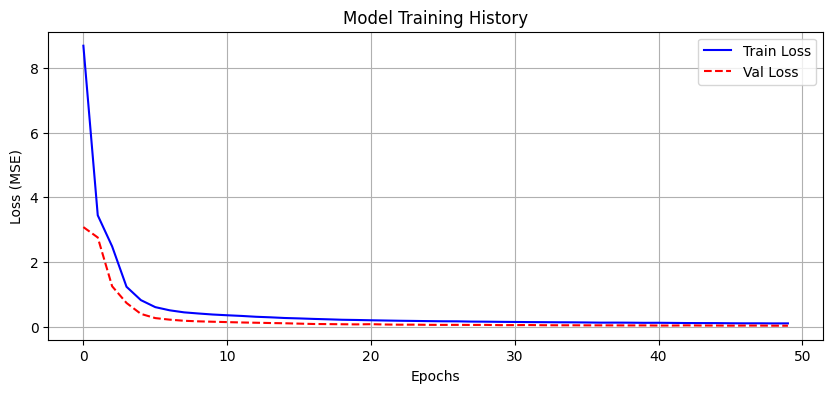

Training history plot generated.


In [43]:
manager.plot_history()
print("Training history plot generated.")

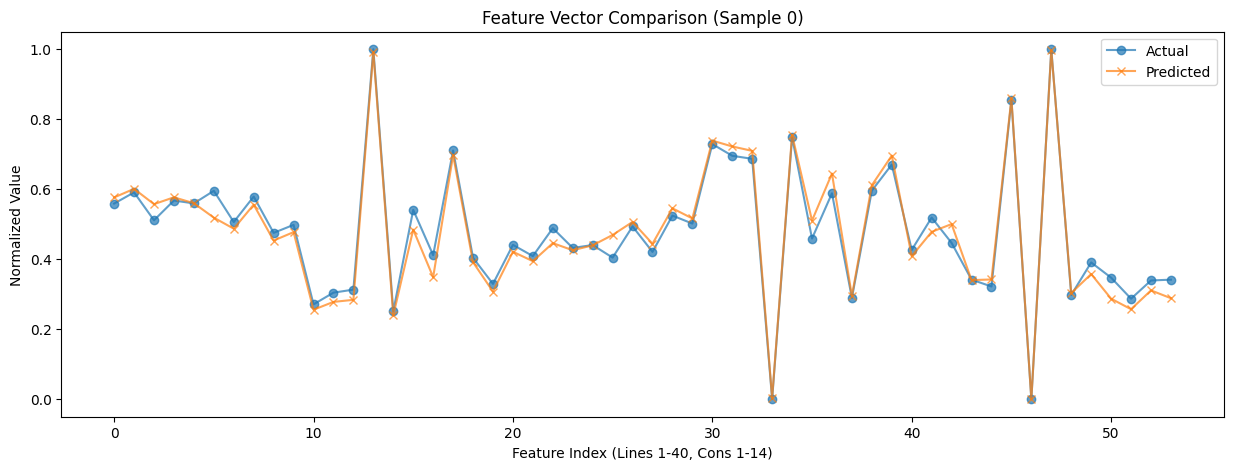

Sample comparison plot generated.


In [44]:
manager.plot_sample_comparison(y_val_windowed, y_pred, sample_idx=0)
print("Sample comparison plot generated.")

In [45]:
torch.save(manager.model.state_dict(), 'xtm_model.pt')
print("Model saved to xtm_model.pt")

Model saved to xtm_model.pt


In [46]:
def inject_attacks_into_data(benign_data, atk_vectors_pu, scaler, config, attack_ratio, num_attacks_per_sample=1):
    # Make a copy of benign_data to inject attacks into
    data_with_attacks = benign_data.copy()

    # Get number of samples and input dimension
    num_samples = len(benign_data)
    input_dim = benign_data.shape[1]

    # Initialize true_fdi_locations as a NumPy array of zeros
    true_fdi_locations = np.zeros((num_samples, input_dim), dtype=np.float32)

    # Calculate how many samples to attack
    num_attacks_to_inject = int(num_samples * attack_ratio)

    # Set random seed for reproducibility
    np.random.seed(config['RANDOM_SEED'])
    # Randomly select indices in the data set to inject attacks
    attack_indices = np.random.choice(num_samples, num_attacks_to_inject, replace=False)

    print(f"Injecting {num_attacks_to_inject} attacks into the dataset...")

    for idx in attack_indices:
        combined_attack_pu = np.zeros_like(benign_data[idx])
        combined_attack_mask = np.zeros_like(benign_data[idx], dtype=np.float32)

        for _ in range(num_attacks_per_sample):
            # Select a random attack vector from the loaded atk_vectors_pu
            random_attack_idx = np.random.choice(len(atk_vectors_pu))
            current_attack_pu = atk_vectors_pu[random_attack_idx]

            # Accumulate attack vectors
            combined_attack_pu += current_attack_pu

            # Update combined attack mask
            current_attack_mask = (current_attack_pu != 0).astype(np.float32)
            combined_attack_mask = np.logical_or(combined_attack_mask, current_attack_mask).astype(np.float32)

        # Denormalize the benign data at this specific time step using the scaler
        y_benign_denorm = scaler.inverse_transform(benign_data[idx].reshape(1, -1)).flatten()

        # Add the combined attack to the denormalized benign data
        y_attacked_denorm = y_benign_denorm + combined_attack_pu

        # Re-normalize the attacked data using the scaler
        y_attacked_norm = scaler.transform(y_attacked_denorm.reshape(1, -1)).flatten()

        # Replace the original benign sample with the attacked sample in the new dataset
        data_with_attacks[idx] = y_attacked_norm

        # Store the combined attack mask
        true_fdi_locations[idx] = combined_attack_mask

    print(f"Number of attacked samples: {np.sum((true_fdi_locations.sum(axis=1) > 0).astype(int))}")
    print(f"Number of benign samples: {num_samples - np.sum((true_fdi_locations.sum(axis=1) > 0).astype(int))}")

    return data_with_attacks, true_fdi_locations

In [47]:
print("Preparing LDM Training and Validation Data...")

# 1. Prepare Validation Data
y_val_with_attacks, y_true_fdi_locations = inject_attacks_into_data(
    benign_data=y_val_windowed,
    atk_vectors_pu=atk_vectors_pu,
    scaler=scaler, # Pass scaler instead of mu and sig
    config=config,
    attack_ratio=0.3, # Keep validation attack ratio at 30%
    num_attacks_per_sample=2 # Use 2 attacks per sample for consistency with training
)

print(f"y_val_with_attacks shape: {y_val_with_attacks.shape}")
print(f"y_true_fdi_locations shape: {y_true_fdi_locations.shape}")

# 2. Prepare Training Data for LDM
X_train_ldm_input, y_train_ldm_labels = inject_attacks_into_data(
    benign_data=y_train_windowed, # Use y_train_windowed as the base for injecting attacks
    atk_vectors_pu=atk_vectors_pu,
    scaler=scaler, # Pass scaler instead of mu and sig
    config=config,
    attack_ratio=0.7, # Use 0.7 attack ratio for training the LDM
    num_attacks_per_sample=2 # Use 2 attacks per sample for training
)

print(f"X_train_ldm_input shape: {X_train_ldm_input.shape}")
print(f"y_train_ldm_labels shape: {y_train_ldm_labels.shape}")

# 3. Generate predictions from the XTM model on the *benign* training data (train_predictions_xtm)
# Create a DataLoader for the benign training input (X_train_windowed) to get predictions
benign_train_dataset_for_pred = TensorDataset(X_train_tensor, y_train_tensor) # y_train_tensor is not used for prediction input, but required for TensorDataset
benign_train_loader_for_pred = DataLoader(benign_train_dataset_for_pred, batch_size=batch_size, shuffle=False)

print("Generating XTM model predictions on benign training data...")
train_predictions_xtm = manager.predict(benign_train_loader_for_pred)

print(f"train_predictions_xtm shape: {train_predictions_xtm.shape}")

print("LDM training and validation data preparation complete.")

Preparing LDM Training and Validation Data...
Injecting 511 attacks into the dataset...
Number of attacked samples: 511
Number of benign samples: 1193
y_val_with_attacks shape: (1704, 54)
y_true_fdi_locations shape: (1704, 54)
Injecting 4872 attacks into the dataset...
Number of attacked samples: 4872
Number of benign samples: 2088
X_train_ldm_input shape: (6960, 54)
y_train_ldm_labels shape: (6960, 54)
Generating XTM model predictions on benign training data...
train_predictions_xtm shape: (6960, 54)
LDM training and validation data preparation complete.


In [48]:
X_train_ldm_input.max()

np.float32(38.749557)

In [49]:
import torch.optim as optim
from tqdm import tqdm
class LDM_Network(nn.Module):
    def __init__(self, input_dim, output_heads):
        super(LDM_Network, self).__init__()
        # Concat pred_inp and fdi_inp doubles the input dimension
        self.fc1 = nn.Linear(input_dim * 2, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)

        # Multiple output heads for multi-label classification
        self.heads = nn.ModuleList([nn.Linear(128, 1) for _ in range(output_heads)])
        self.relu = nn.ReLU()
        # Removed self.sigmoid here as BCEWithLogitsLoss handles it internally

    def forward(self, pred_inp, fdi_inp):
        x = torch.cat((pred_inp, fdi_inp), dim=1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        # Returns a list of raw logits (one per head)
        return [head(x) for head in self.heads]


class LDM_Model:
    def __init__(self, ldm_data, input_shape=(54,), output_heads=54, algorithm='xtm',
                 epochs=100, batch_size=32, learning_rate=1e-3, training=False):
        self.ldm_data = ldm_data
        self.input_dim = input_shape[0]
        self.output_heads = output_heads
        self.algorithm = algorithm
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = LDM_Network(self.input_dim, self.output_heads).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)

        # Calculate pos_weight based on the frequency of positive labels
        # Sum all positive labels across all features and samples, then total samples * features
        num_positive_samples = ldm_data.fdi_location_train.sum()
        total_elements = ldm_data.fdi_location_train.size # This gives total number of elements in array

        if num_positive_samples == 0:
            self.pos_weight = torch.tensor(1.0, device=self.device) # Handle case with no positive samples
        else:
            num_negative_samples = total_elements - num_positive_samples
            self.pos_weight = torch.tensor(num_negative_samples / num_positive_samples, device=self.device)
        print(f"Init pos weight = {self.pos_weight}")

        # Use BCEWithLogitsLoss with pos_weight
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

        self.checkpoint_path = os.path.join(os.getcwd(), "checkpoint", f"ldm_{self.algorithm}.pth")

        if training:
            print(f"Ready to train LDM model for {self.algorithm}...")
        else:
            print(f"Loading LDM model from {self.checkpoint_path}...")
            self.model.load_state_dict(torch.load(self.checkpoint_path))
            self.model.eval()
    def train(self, save_model=False):
        # Convert data to PyTorch Tensors
        train_pred = torch.FloatTensor(self.ldm_data.train_predictions).to(self.device)
        train_real = torch.FloatTensor(self.ldm_data.train_set).to(self.device)
        train_labels = torch.FloatTensor(self.ldm_data.fdi_location_train).to(self.device)

        history = {'loss': []}

        for epoch in range(self.epochs):
            self.model.train()
            total_loss = 0

            permutation = torch.randperm(train_pred.size(0))
            for i in range(0, train_pred.size(0), self.batch_size):
                indices = permutation[i:i+self.batch_size]
                batch_pred, batch_real, batch_y = train_pred[indices], train_real[indices], train_labels[indices]

                self.optimizer.zero_grad()

                # 1. Forward pass returns a list, stack it to (Batch, Heads)
                outputs_list = self.model(batch_pred, batch_real)
                outputs = torch.stack(outputs_list, dim=1).squeeze(-1)

                # 2. Vectorized loss: BCEWithLogitsLoss handles 2D tensors automatically
                loss = self.criterion(outputs, batch_y)

                loss.backward()

                # 3. GRADIENT CLIPPING (The "Seatbelt")
                # This prevents the "billions" in logits by capping the update size
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

                self.optimizer.step()
                total_loss += loss.item()

            # Correct average loss calculation
            num_batches = (train_pred.size(0) + self.batch_size - 1) // self.batch_size
            avg_loss = total_loss / num_batches
            history['loss'].append(avg_loss)
            print(f"Epoch {epoch+1}/{self.epochs}, Loss: {avg_loss:.4f}")

        if save_model:
            # Create directory if it doesn't exist
            os.makedirs(os.path.dirname(self.checkpoint_path), exist_ok=True)
            torch.save(self.model.state_dict(), self.checkpoint_path)
            pd.DataFrame(history).to_excel(os.path.join(os.getcwd(), 'checkpoint', f'{self.algorithm}_history.xlsx'))


    def predict(self, real_data, predicted_data, threshold=0.5):
        self.model.eval()
        real_tensor = torch.FloatTensor(real_data).to(self.device)
        pred_tensor = torch.FloatTensor(predicted_data).to(self.device)

        with torch.no_grad():
            outputs = self.model(pred_tensor, real_tensor)
            # Apply sigmoid to raw logits to get probabilities for prediction
            probabilities = [torch.sigmoid(out.squeeze()) for out in outputs]
            # Stack heads: (Heads, Batch, 1) -> (Batch, Heads)
            raw_preds = torch.stack(probabilities).cpu().numpy().T

        # Apply thresholding
        return (raw_preds > threshold).astype(int)

In [50]:
print("Initializing and training LDM model with pos_weight...")

# Define a simple data container for LDM_Model
class LDMData:
    def __init__(self, train_predictions, train_set, fdi_location_train):
        self.train_predictions = train_predictions
        self.train_set = train_set
        self.fdi_location_train = fdi_location_train

# Create the LDMData object using the prepared training data
ldm_train_data = LDMData(
    train_predictions=train_predictions_xtm,
    train_set=X_train_ldm_input, # This contains the 'real_data' with injected attacks
    fdi_location_train=y_train_ldm_labels
)

# Ensure checkpoint directory exists
if not os.path.exists('checkpoint'):
    os.makedirs('checkpoint')

# Initialize and train the LDM model
ldm_model_instance = LDM_Model(
    ldm_data=ldm_train_data,
    input_shape=(INPUT_DIM,),
    output_heads=INPUT_DIM,
    algorithm='xtm', # Or another descriptive name
    epochs=20,
    batch_size=64,
    learning_rate=0.001,
    training=True # Indicate that we are training
)

ldm_model_instance.train(save_model=True)
print("LDM model training completed and saved.")

Initializing and training LDM model with pos_weight...
Init pos weight = 2.5523293018341064
Ready to train LDM model for xtm...
Epoch 1/20, Loss: 0.7861
Epoch 2/20, Loss: 0.5301
Epoch 3/20, Loss: 0.4436
Epoch 4/20, Loss: 0.3925
Epoch 5/20, Loss: 0.3507
Epoch 6/20, Loss: 0.3181
Epoch 7/20, Loss: 0.2966
Epoch 8/20, Loss: 0.2740
Epoch 9/20, Loss: 0.2557
Epoch 10/20, Loss: 0.2396
Epoch 11/20, Loss: 0.2268
Epoch 12/20, Loss: 0.2107
Epoch 13/20, Loss: 0.1995
Epoch 14/20, Loss: 0.1881
Epoch 15/20, Loss: 0.1827
Epoch 16/20, Loss: 0.1724
Epoch 17/20, Loss: 0.1637
Epoch 18/20, Loss: 0.1575
Epoch 19/20, Loss: 0.1517
Epoch 20/20, Loss: 0.1462
LDM model training completed and saved.


In [51]:
print("Evaluating LDM model performance on validation set...")

# Make predictions using the trained LDM model on the validation data
# y_val_with_attacks: the 'real_data' with potential attacks
# y_pred: the XTM model's predictions (benign baseline)
ldm_predictions_binary = ldm_model_instance.predict(real_data=y_val_with_attacks, predicted_data=y_pred)

print(f"LDM predictions shape: {ldm_predictions_binary.shape}")

# Evaluate per-feature classification metrics
print("\nPer-Feature FDI Localization Metrics (LDM):")
metrics_df = pd.DataFrame(columns=['Feature', 'Precision', 'Recall', 'F1-Score', 'Accuracy'])

for i in range(INPUT_DIM):
    y_true_feature = y_true_fdi_locations[:, i]
    y_pred_feature = ldm_predictions_binary[:, i]

    precision = precision_score(y_true_feature, y_pred_feature, zero_division=0)
    recall = recall_score(y_true_feature, y_pred_feature, zero_division=0)
    f1 = f1_score(y_true_feature, y_pred_feature, zero_division=0)
    accuracy = accuracy_score(y_true_feature, y_pred_feature)

    metrics_df.loc[i] = [f'Feature_{i+1}', precision, recall, f1, accuracy]

# Display overall average metrics
print("\nOverall Average Metrics:")
print(metrics_df.mean(numeric_only=True))

# Display metrics for the first few features and then overall averages
print("\nMetrics for first 5 features:")
print(metrics_df.head())

print("\nLDM model evaluation completed.")

Evaluating LDM model performance on validation set...
LDM predictions shape: (1704, 54)

Per-Feature FDI Localization Metrics (LDM):

Overall Average Metrics:
Precision    0.887260
Recall       0.964876
F1-Score     0.922622
Accuracy     0.979764
dtype: float64

Metrics for first 5 features:
     Feature  Precision    Recall  F1-Score  Accuracy
0  Feature_1   0.846154  0.942857  0.891892  0.967136
1  Feature_2   0.881481  0.948207  0.913628  0.973592
2  Feature_3   0.737952  0.976096  0.840480  0.945423
3  Feature_4   0.881119  0.992126  0.933333  0.978873
4  Feature_5   0.915441  0.976471  0.944972  0.982981

LDM model evaluation completed.


In [52]:
print("Optimizing LDM Prediction Threshold...")

# Define a range of thresholds to explore
ldm_thresholds = np.arange(0.1, 1.0, 0.1) # From 0.1 to 0.9
ldm_thresholds = np.append(ldm_thresholds, [0.01, 0.05, 0.95, 0.99]) # Add some extreme values
ldm_thresholds.sort()

threshold_results = []

for current_threshold in ldm_thresholds:
    print(f"\n--- Evaluating with LDM Prediction Threshold: {current_threshold:.2f} ---")

    # Make predictions using the trained LDM model with the current threshold
    ldm_predictions_binary_thresh = ldm_model_instance.predict(real_data=y_val_with_attacks, predicted_data=y_pred, threshold=current_threshold)

    # Calculate per-feature classification metrics for the current threshold
    metrics_data = []
    for i in range(INPUT_DIM):
        y_true_feature = y_true_fdi_locations[:, i]
        y_pred_feature = ldm_predictions_binary_thresh[:, i]

        precision = precision_score(y_true_feature, y_pred_feature, zero_division=0)
        recall = recall_score(y_true_feature, y_pred_feature, zero_division=0)
        f1 = f1_score(y_true_feature, y_pred_feature, zero_division=0)
        accuracy = accuracy_score(y_true_feature, y_pred_feature)
        metrics_data.append({'Feature': f'Feature_{i+1}', 'Precision': precision, 'Recall': recall, 'F1-Score': f1, 'Accuracy': accuracy})

    metrics_df_thresh = pd.DataFrame(metrics_data)

    # Store overall average metrics for this threshold
    overall_avg = metrics_df_thresh.mean(numeric_only=True)
    threshold_results.append({
        'Threshold': current_threshold,
        'Avg Precision': overall_avg['Precision'],
        'Avg Recall': overall_avg['Recall'],
        'Avg F1-Score': overall_avg['F1-Score'],
        'Avg Accuracy': overall_avg['Accuracy']
    })

    print("Overall Average Metrics for this Threshold:")
    print(overall_avg)

# Display summary of all threshold results
results_df = pd.DataFrame(threshold_results)
print("\n--- Summary of LDM Performance Across Different Thresholds ---")
display(results_df.round(4))

print("LDM threshold optimization exploration completed.")

Optimizing LDM Prediction Threshold...

--- Evaluating with LDM Prediction Threshold: 0.01 ---
Overall Average Metrics for this Threshold:
Precision    0.564730
Recall       0.998495
F1-Score     0.712261
Accuracy     0.901148
dtype: float64

--- Evaluating with LDM Prediction Threshold: 0.05 ---
Overall Average Metrics for this Threshold:
Precision    0.702808
Recall       0.995080
F1-Score     0.818601
Accuracy     0.946064
dtype: float64

--- Evaluating with LDM Prediction Threshold: 0.10 ---
Overall Average Metrics for this Threshold:
Precision    0.758229
Recall       0.992711
F1-Score     0.856459
Accuracy     0.958714
dtype: float64

--- Evaluating with LDM Prediction Threshold: 0.20 ---
Overall Average Metrics for this Threshold:
Precision    0.814310
Recall       0.986792
F1-Score     0.890334
Accuracy     0.969418
dtype: float64

--- Evaluating with LDM Prediction Threshold: 0.30 ---
Overall Average Metrics for this Threshold:
Precision    0.845834
Recall       0.979482
F1-Sc

,Threshold,Avg Precision,Avg Recall,Avg F1-Score,Avg Accuracy
0,0.01,0.5647,0.9985,0.7123,0.9011
1,0.05,0.7028,0.9951,0.8186,0.9461
2,0.10,0.7582,0.9927,0.8565,0.9587
3,0.20,0.8143,0.9868,0.8903,0.9694
4,0.30,0.8458,0.9795,0.9060,0.9744
5,0.40,0.8681,0.9720,0.9154,0.9775
6,0.50,0.8873,0.9649,0.9226,0.9798
7,0.60,0.9059,0.9545,0.9277,0.9815
8,0.70,0.9271,0.9356,0.9289,0.9826
9,0.80,0.9453,0.9072,0.9235,0.9819


LDM threshold optimization exploration completed.
